In [1]:
!pip install datasets rapidfuzz --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.0 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import time
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [4]:
from datasets import load_dataset
from rapidfuzz.distance import Levenshtein

In [5]:
BASE_DIR   = Path('/content/sphinx_data')
RAW_DIR    = BASE_DIR / 'raw'
CLEAN_DIR  = BASE_DIR / 'clean'
OUTPUT_DIR = BASE_DIR / 'output'

In [6]:
for d in [RAW_DIR, CLEAN_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [7]:
print('Show Paths :')
for d in [RAW_DIR, CLEAN_DIR, OUTPUT_DIR]:
    print(f'  {d}')

Show Paths :
  /content/sphinx_data/raw
  /content/sphinx_data/clean
  /content/sphinx_data/output


In [8]:
print('Getting BBAW from Hugging Face...')
ds_bbaw_raw = load_dataset(
    'phiwi/bbaw_egyptian',
    split='all',
    trust_remote_code=True
)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'phiwi/bbaw_egyptian' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'phiwi/bbaw_egyptian' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Getting BBAW from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.75M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100736 [00:00<?, ? examples/s]

In [9]:
df_bbaw = ds_bbaw_raw.to_pandas()
df_bbaw.to_parquet(RAW_DIR / 'bbaw_raw.parquet', index=False)

In [10]:
print(f'bbaw_egyptian downloaded: {len(df_bbaw):,} registers ')
print(f'Columns: {list(df_bbaw.columns)}')

bbaw_egyptian downloaded: 100,736 registers 
Columns: ['transcription', 'translation', 'hieroglyphs']


In [11]:
print('D++Fetching  tla-Earlier_Egyptian_original-v18-premium...')
ds_tla_raw = load_dataset(
    'thesaurus-linguae-aegyptiae/tla-Earlier_Egyptian_original-v18-premium',
    split='train',
    trust_remote_code=True
)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'thesaurus-linguae-aegyptiae/tla-Earlier_Egyptian_original-v18-premium' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'thesaurus-linguae-aegyptiae/tla-Earlier_Egyptian_original-v18-premium' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


D++Fetching  tla-Earlier_Egyptian_original-v18-premium...


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/5.92M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [12]:
df_tla = ds_tla_raw.to_pandas()
df_tla.to_parquet(RAW_DIR / 'tla_raw.parquet', index=False)

In [13]:
print(f'tla-v18 download {len(df_tla):,} registres')
print(f'Columns: {list(df_tla.columns)}')


tla-v18 download 12,773 registres
Columns: ['hieroglyphs', 'transliteration', 'lemmatization', 'UPOS', 'glossing', 'translation', 'dateNotBefore', 'dateNotAfter']


In [15]:
print('EDA: bbaw_egyptian')
print('\n-- Shape y dtypes --')
print(f'Filas: {len(df_bbaw):,}  |  Columnas: {len(df_bbaw.columns)}')
print(df_bbaw.dtypes)
print('\n-- Head --')
print(df_bbaw.head())

EDA: bbaw_egyptian

-- Shape y dtypes --
Filas: 100,736  |  Columnas: 3
transcription    object
translation      object
hieroglyphs      object
dtype: object

-- Head --
                                       transcription  \
0                 ⸢pḏ,wt-9⸣   n =f   [⸮ḥtr?]   ⸢m⸣     
1                       ḥtr tp,j ꜥꜣ n ḥm =f Ꜥꜣ-nḫt,w   
2  ⸢wr⸣.pl ⸢ꜥꜣi̯⸣.pl n.w ⸢Rṯn,w⸣ ⸢jni̯⸣ ⸢ḥm⸣ ⸢=f⸣...   
3                       ḏd-mdw jn ꜣs,t wr,t mw,t-nṯr   
4  sꜣ =j mri̯ =j Rꜥw-msi̯-sw-mri̯-Jmn ⸢ꜥḥꜥ,w⸣ =k ...   

                                         translation hieroglyphs  
0  ... die Neun-Bogenvölker ... zu ihm ... Pferde...              
1  [Pferde]: Das erste große Pfergespann seiner M...              
2  [Gefangene]: Die großen Oberhäupter von Retjen...              
3  Worte sprechen durch Isis, die Große, die Gott...              
4  "Mein geliebter Sohn Ramses-meriamun, deine Le...              


In [16]:
print('\n-- Muestra de 3 filas --')
print(df_bbaw.head(5).to_string())


-- Muestra de 3 filas --
                                                  transcription                                                                                            translation hieroglyphs
0                            ⸢pḏ,wt-9⸣   n =f   [⸮ḥtr?]   ⸢m⸣                                                ... die Neun-Bogenvölker ... zu ihm ... Pferdegespann ...            
1                                  ḥtr tp,j ꜥꜣ n ḥm =f Ꜥꜣ-nḫt,w                       [Pferde]: Das erste große Pfergespann seiner Majestät (namens) 'Groß an Siegen'.            
2  ⸢wr⸣.pl ⸢ꜥꜣi̯⸣.pl n.w ⸢Rṯn,w⸣ ⸢jni̯⸣ ⸢ḥm⸣ ⸢=f⸣ ⸢m⸣ ⸢sqr-ꜥnḫ⸣  [Gefangene]: Die großen Oberhäupter von Retjenu, die seine Majestät als Kriegsgefangene gebracht hat.            
3                                  ḏd-mdw jn ꜣs,t wr,t mw,t-nṯr                                                Worte sprechen durch Isis, die Große, die Gottesmutter:            
4  sꜣ =j mri̯ =j Rꜥw-msi̯-sw-mri̯-Jmn ⸢ꜥḥꜥ,w⸣ =k mj  sꜣ =j Ḥr,w              "M

In [18]:
df_bbaw.sample(5)

,transcription,translation,hieroglyphs
66194,"jw sḥwꜣ.pl ry,t",(Es sind) Fäulnisprodukte des Eiters.,M17 -Z7 S29 -V28 -V4 -G1 -Aa2 :Z2 D21 -M17 -M1...
60788,"sḥḏ-ḥm(,w)-kꜣ Mr-sw-ꜥnḫ",Der Aufseher der Totenpriester Mersu-anch.,
74323,ḥmi̯.n =s tw,"""Es hat dich vertrieben!""",N42 -G17 -D55 -N35 O34 Z7 -X1
18276,"zni̯.n =j r jri̯,t jt.pl =(j) jri̯.n =j m-mꜣꜥ,...",I surpassed the deeds of my ancestors and I ha...,O34 :N35 :X4 :N35 A1 D21 D4 :X1 M17 -X1 :I9 -A...
89862,jwi̯.n =(j) nḏri̯ =(j) jm =k ḏi̯ =(j) n =k jb...,"Ich bin gekommen, damit ich dich fasse und dir...",


In [19]:
null_stats = pd.DataFrame({
    'nulos':  df_bbaw.isna().sum(),
    'vacios': (df_bbaw == '').sum(),
    'unicos': df_bbaw.nunique()
})

In [20]:
null_stats['pct_util'] = (
    1 - (null_stats['nulos'] + null_stats['vacios']) / len(df_bbaw)
) * 100
print(null_stats.to_string())


               nulos  vacios  unicos   pct_util
transcription      7       0   89446  99.993051
translation       21       0   85632  99.979153
hieroglyphs        7   65226   32916  35.243607


In [21]:
mask_con_glifos = (
    df_bbaw['hieroglyphs'].notna() &
    (df_bbaw['hieroglyphs'].str.strip() != '')
)

In [22]:
n_con_glifos = mask_con_glifos.sum()
n_sin_glifos = (~mask_con_glifos).sum()

In [23]:
print('\n-- Coverage - IDs Gardiner --')
print(f'  Con glifos : {n_con_glifos:,}  ({n_con_glifos/len(df_bbaw)*100:.1f}%)')
print(f'  Sin glifos : {n_sin_glifos:,}  ({n_sin_glifos/len(df_bbaw)*100:.1f}%)')



-- Coverage - IDs Gardiner --
  Con glifos : 35,503  (35.2%)
  Sin glifos : 65,233  (64.8%)


In [24]:
df_bbaw_con = df_bbaw[mask_con_glifos].copy()
df_bbaw_con['n_tokens_gardiner'] = df_bbaw_con['hieroglyphs'].str.split().str.len()

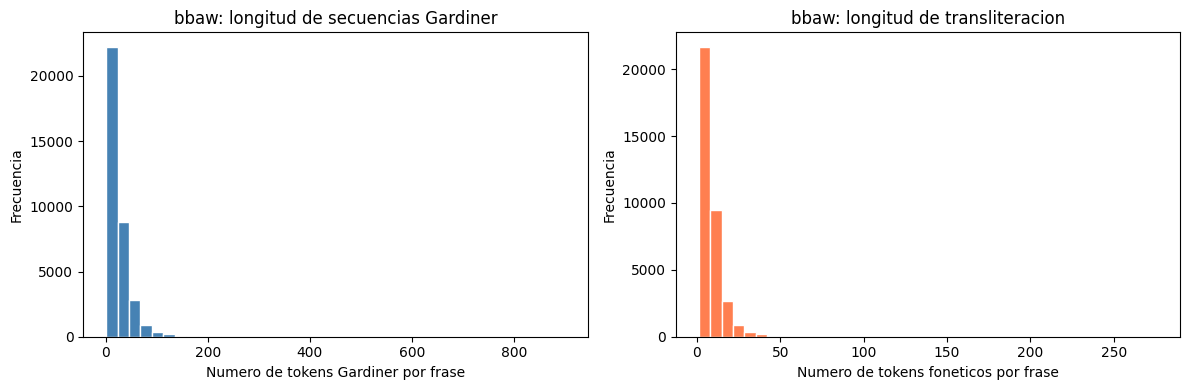

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_bbaw_con['n_tokens_gardiner'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title('bbaw: longitud de secuencias Gardiner')
axes[0].set_xlabel('Numero de tokens Gardiner por frase')
axes[0].set_ylabel('Frecuencia')

len_translit = df_bbaw_con['transcription'].str.split().str.len()
axes[1].hist(len_translit, bins=40, color='coral', edgecolor='white')
axes[1].set_title('bbaw: longitud de transliteracion')
axes[1].set_xlabel('Numero de tokens foneticos por frase')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bbaw_eda_longitudes.png', dpi=120)
plt.show()

In [26]:
# 5.6 IDs Gardiner mas frecuentes
all_ids = ' '.join(df_bbaw_con['hieroglyphs'].tolist()).split()
top_ids = Counter(all_ids).most_common(20)

In [27]:
print('\n-- Top 20 IDs Gardiner mas frecuentes --')
for gid, cnt in top_ids:
    print(f'  {gid:<12} {cnt:>7,}')


-- Top 20 IDs Gardiner mas frecuentes --
  -X1           40,827
  -N35          23,963
  -Z1           23,268
  -M17          20,155
  //            19,061
  -Z7           19,061
  -?]           19,011
  N35           17,617
  -[?           16,515
  -D21          15,139
  I9            14,318
  :X1           14,294
  M17           14,235
  G17           13,870
  D21           12,218
  -G1           11,564
  :Z2           11,229
  S29           11,054
  *?]           10,622
  [?            10,308


In [28]:
print('\n-- Columnas a conservar de bbaw --')
print('  hieroglyphs   -> clave del Trie (IDs Gardiner)')
print('  transcription -> transliteracion fonética (valor del nodo)')
print('  translation   -> DESCARTADA (aleman, GPT hace la traduccion)')


-- Columnas a conservar de bbaw --
  hieroglyphs   -> clave del Trie (IDs Gardiner)
  transcription -> transliteracion fonética (valor del nodo)
  translation   -> DESCARTADA (aleman, GPT hace la traduccion)


In [29]:
print('EDA: tla-Earlier_Egyptian_original-v18-premium')

EDA: tla-Earlier_Egyptian_original-v18-premium


In [30]:
print('\n-- Shape y dtypes --')
print(f'Filas: {len(df_tla):,}  |  Columnas: {len(df_tla.columns)}')
print(df_tla.dtypes)


-- Shape y dtypes --
Filas: 12,773  |  Columnas: 8
hieroglyphs        object
transliteration    object
lemmatization      object
UPOS               object
glossing           object
translation        object
dateNotBefore      object
dateNotAfter       object
dtype: object


In [33]:
print('\n-- Four rows samples--')
print(df_tla.head(4).to_string())


-- Four rows samples--
                                     hieroglyphs                                                          transliteration                                                                                                                        lemmatization                                                   UPOS                                                glossing                                                                                                                translation dateNotBefore dateNotAfter
0                                      𓐩𓏌𓀜 𓂧 𓂋 𓋴                                                           nḏ (w)di̯ r =s                                                                                                 90880|nḏ 51510|wdi̯ 91901|r 10090|=s                                     VERB VERB ADP PRON                  V\tam.pass V\tam.pass PREP:stpr -3sg.f                                                                            (es) werde zerriebe

In [34]:
print('\nNulos per columns --')
print(df_tla.isna().sum().to_string())


Nulos per columns --
hieroglyphs        0
transliteration    0
lemmatization      0
UPOS               0
glossing           0
translation        0
dateNotBefore      0
dateNotAfter       0


In [35]:
# 6.3 Distribucion temporal
df_tla['dateNotBefore'] = pd.to_numeric(df_tla['dateNotBefore'], errors='coerce')
df_tla['dateNotAfter']  = pd.to_numeric(df_tla['dateNotAfter'],  errors='coerce')

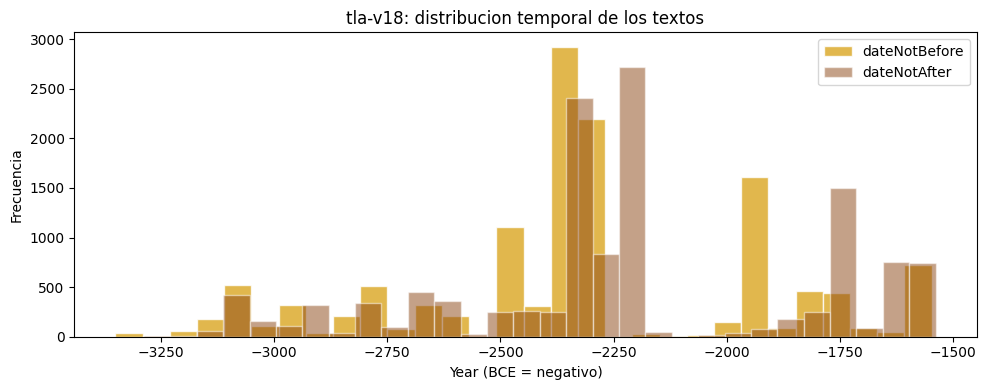

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_tla['dateNotBefore'].dropna(), bins=30,
        color='goldenrod', edgecolor='white', alpha=0.8, label='dateNotBefore')
ax.hist(df_tla['dateNotAfter'].dropna(),  bins=30,
        color='saddlebrown', edgecolor='white', alpha=0.5, label='dateNotAfter')
ax.set_title('tla-v18: distribucion temporal de los textos')
ax.set_xlabel('Year (BCE = negativo)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tla_eda_temporal.png', dpi=120)
plt.show()


In [37]:
# 6.4 Distribucion UPOS
all_pos    = ' '.join(df_tla['UPOS'].dropna().tolist()).split()
pos_counts = Counter(all_pos)
labels, values = zip(*sorted(pos_counts.items(), key=lambda x: -x[1]))

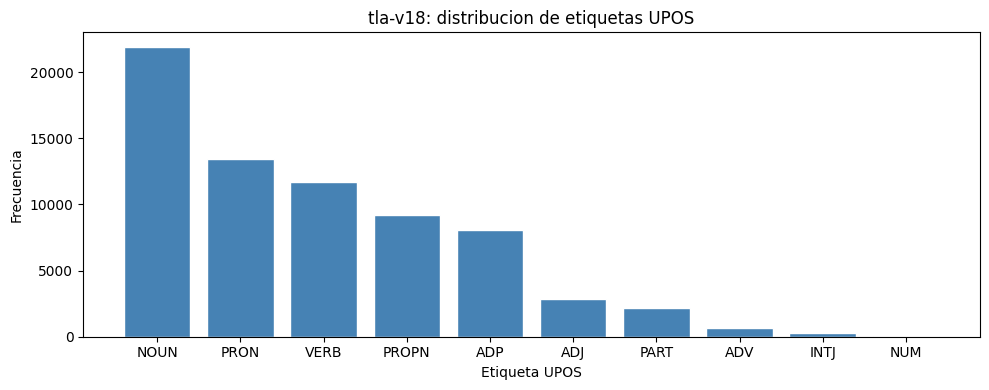

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color='steelblue', edgecolor='white')
ax.set_title('tla-v18: distribucion de etiquetas UPOS')
ax.set_xlabel('Etiqueta UPOS')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tla_eda_upos.png', dpi=120)
plt.show()

In [39]:
# 6.5 Estructura del campo lemmatization
print('\n-- Estructura del campo lemmatization (3 ejemplos) --')
for ex in df_tla['lemmatization'].head(3):
    print(f'  {ex}')
print('  Formato: TLA_ID|transliteracion separados por espacio')


-- Estructura del campo lemmatization (3 ejemplos) --
  90880|nḏ 51510|wdi̯ 91901|r 10090|=s
  78890|n 174900|ṯw 400007|m 10100|=sn
  113110|ḫꜣ 400082|m 168810|tʾ 110300|ḥnq.t 162930|kꜣ 107|ꜣpd 400055|n 25090|ꞽmꜣḫ.w 72420|ꞽm.ꞽ-rʾ-šnꜥ 400161|Ꞽmn-m-ḥꜣ.t 66750|mꜣꜥ-ḫrw
  Formato: TLA_ID|transliteracion separados por espacio


In [40]:
# 6.6 Columnas a conservar
print('\n-- Columnas a conservar de tla-v18 --')
print('  transliteration -> join key con bbaw')
print('  lemmatization   -> TLA Lemma ID + transliteracion canonica')
print('  UPOS            -> Part of Speech para cadenas de Markov')
print('  dateNotBefore   -> metadato temporal del nodo')
print('  dateNotAfter    -> metadato temporal del nodo')
print('  hieroglyphs     -> DESCARTADO (Unicode, no IDs Gardiner)')
print('  glossing        -> DESCARTADO (uso interno BBAW)')
print('  translation     -> DESCARTADO (aleman, GPT hace la traduccion)')


-- Columnas a conservar de tla-v18 --
  transliteration -> join key con bbaw
  lemmatization   -> TLA Lemma ID + transliteracion canonica
  UPOS            -> Part of Speech para cadenas de Markov
  dateNotBefore   -> metadato temporal del nodo
  dateNotAfter    -> metadato temporal del nodo
  hieroglyphs     -> DESCARTADO (Unicode, no IDs Gardiner)
  glossing        -> DESCARTADO (uso interno BBAW)
  translation     -> DESCARTADO (aleman, GPT hace la traduccion)


In [41]:
# CELDA 7 - Limpieza de bbaw_egyptian
# Produce df_bbaw_clean con columnas:
#   gardiner_seq   : 'D35 D21 D37 G1'  (tokens limpios, sin operadores -/*/&)
#   translit_raw   : transliteracion original
#   translit_clean : transliteracion normalizada (sin marcadores criticos)

In [42]:
df_b = df_bbaw[
    df_bbaw['hieroglyphs'].notna() &
    (df_bbaw['hieroglyphs'].str.strip() != '')
].copy()

In [43]:
print(f'Registros con glifos Gardiner: {len(df_b):,}')

Registros con glifos Gardiner: 35,503


In [44]:
df_b = df_b[['hieroglyphs', 'transcription']].copy()
df_b.columns = ['gardiner_raw', 'translit_raw']

In [45]:
def clean_gardiner_seq(raw: str) -> str:
    """
    Extrae solo los IDs Gardiner validos de una secuencia raw.
    El dataset bbaw usa operadores de composicion:
      -D37  = signo en posicion inferior
      *V28  = ligatura horizontal
      &W11  = ligatura vertical
      [?    = inicio de lectura dudosa
      ]     = fin de lectura dudosa
    Un ID Gardiner valido: letra(s) + numero(s) + variante opcional.
    Ejemplos validos: D21, G17, Aa1, NL17
    """
    if not isinstance(raw, str):
        return ''
    tokens = re.findall(r'[A-Za-z]{1,3}[0-9]{1,3}[a-z]?', raw)
    return ' '.join(tokens)

In [46]:
df_b['gardiner_seq'] = df_b['gardiner_raw'].apply(clean_gardiner_seq)

In [47]:
mask_ok = df_b['gardiner_seq'].str.strip() != ''
df_b    = df_b[mask_ok].copy()
print(f'Registros tras limpiar secuencias Gardiner: {len(df_b):,}')

Registros tras limpiar secuencias Gardiner: 35,219


In [48]:
# 7.4 Limpiar la transliteracion
# Marcadores criticos del corpus que hay que eliminar:
# ((...)) texto sobre la linea
# [[...]] tachado
# {{...}} haplografia
# [...] texto perdido
# {...} texto sobrante
# <...> texto omitido/editorial
# (...) texto defectivo
# =f, =j, =s sufijos pronominales

In [49]:
CRITIC_PATTERN = re.compile(
    r'\(\([^)]*\)\)|'
    r'\[\[[^\]]*\]\]|'
    r'\{\{[^}]*\}\}|'
    r'\[[^\]]*\]|'
    r'\{[^}]*\}|'
    r'<[^>]*>|'
    r'\([^)]*\)|'
    r'[\u2e22\u2e23][^\u2e24\u2e25]*[\u2e24\u2e25]|'
    r'\u2e2e\?|'
    r'=[a-z]'
)

In [50]:
def clean_transliteration(raw: str) -> str:
    """
    Elimina marcadores criticos filologicos y normaliza la transliteracion.
    Conserva los diacriticos Leiden (Unicode) para nfr, Htp, sDm, etc.
    """
    if not isinstance(raw, str):
        return ''
    s = CRITIC_PATTERN.sub('', raw)
    s = re.sub(r'\s+', ' ', s).strip()
    # Conservar solo tokens que contengan al menos una letra
    tokens = [t for t in s.split() if re.search(r'[a-zA-Z\u0100-\u024F]', t)]
    return ' '.join(tokens)

In [51]:
df_b['translit_clean'] = df_b['translit_raw'].apply(clean_transliteration)

In [52]:
df_b = df_b[df_b['translit_clean'].str.strip() != ''].copy()
print(f'Registros tras limpiar transliteracion: {len(df_b):,}')

Registros tras limpiar transliteracion: 35,085


In [53]:
n_before = len(df_b)
df_b = df_b.drop_duplicates(
    subset=['gardiner_seq', 'translit_clean']
).reset_index(drop=True)
print(f'Duplicados eliminados: {n_before - len(df_b):,}')
print(f'bbaw_clean final: {len(df_b):,} registros')

Duplicados eliminados: 2,740
bbaw_clean final: 32,345 registros


In [54]:
df_b.to_parquet(CLEAN_DIR / 'bbaw_clean.parquet', index=False)

In [55]:
print('\n-- Muestra de bbaw_clean --')
print(df_b[['gardiner_seq', 'translit_clean']].head(5).to_string())


-- Muestra de bbaw_clean --
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    gardiner_seq                                                                                                                                                                                                           

In [56]:
# CELDA 8 - Limpieza de tla-v18-premium
# Produce df_tla_clean con columnas:
#   translit_clean  : join key con bbaw
#   tla_ids         : lista de TLA Lemma IDs
#   lemma_forms     : lista de transliteraciones canonicas de cada lema
#   upos_seq        : secuencia de etiquetas UPOS
#   date_before     : int o NaN
#   date_after      : int o NaN

In [57]:
df_t = df_tla[[
    'transliteration',
    'lemmatization',
    'UPOS',
    'dateNotBefore',
    'dateNotAfter'
]].copy()

In [58]:
# 8.1 Limpiar transliteracion (misma funcion que bbaw)
df_t['translit_clean'] = df_t['transliteration'].apply(clean_transliteration)
df_t = df_t[df_t['translit_clean'].str.strip() != ''].copy()
print(f'tla-v18 tras limpiar transliteracion: {len(df_t):,}')

tla-v18 tras limpiar transliteracion: 12,749


In [59]:
def parse_lemmatization(lem_str: str) -> list:
    """
    Convierte '185810|dd 59920|pn' en
    [{'tla_id': '185810', 'lemma': 'dd'}, {'tla_id': '59920', 'lemma': 'pn'}]
    """
    if not isinstance(lem_str, str) or not lem_str.strip():
        return []
    pairs = []
    for token in lem_str.strip().split():
        parts = token.split('|', 1)
        if len(parts) == 2 and parts[0].strip():
            pairs.append({
                'tla_id': parts[0].strip(),
                'lemma':  parts[1].strip()
            })
    return pairs

In [60]:
df_t['lemma_pairs']  = df_t['lemmatization'].apply(parse_lemmatization)
df_t['tla_ids']      = df_t['lemma_pairs'].apply(
    lambda ps: [p['tla_id'] for p in ps]
)
df_t['lemma_forms']  = df_t['lemma_pairs'].apply(
    lambda ps: [p['lemma'] for p in ps]
)

In [61]:
# 8.4 Limpiar UPOS
df_t['upos_seq'] = df_t['UPOS'].str.strip()

In [62]:
# 8.5 Tipos numericos para fechas
df_t['date_before'] = pd.to_numeric(
    df_t['dateNotBefore'], errors='coerce'
).astype('Int64')
df_t['date_after']  = pd.to_numeric(
    df_t['dateNotAfter'], errors='coerce'
).astype('Int64')

In [63]:
# 8.6 Columnas finales
df_t_clean = df_t[[
    'translit_clean',
    'tla_ids',
    'lemma_forms',
    'upos_seq',
    'date_before',
    'date_after'
]].drop_duplicates(subset=['translit_clean']).reset_index(drop=True)

In [64]:
print(f'tla_clean final: {len(df_t_clean):,} registros unicos')
df_t_clean.to_parquet(CLEAN_DIR / 'tla_clean.parquet', index=False)

tla_clean final: 8,967 registros unicos


In [65]:
print('\n-- Muestra de tla_clean --')
print(df_t_clean[['translit_clean', 'tla_ids', 'upos_seq']].head(4).to_string())



-- Muestra de tla_clean --
                                               translit_clean                                                                                          tla_ids                                                        upos_seq
0                                                    nḏ di̯ r                                                                     [90880, 51510, 91901, 10090]                                              VERB VERB ADP PRON
1                                                   n ṯw ꞽm n                                                                   [78890, 174900, 400007, 10100]                                              PART PRON ADP PRON
2  m tʾ ḥnq.t kꜣ ꜣpd n ꞽmꜣḫ ꞽm.ꞽ-rʾ-šnꜥ.PL ꞽmn-m-ḥꜣ.t mꜣꜥ-ḫrw               [113110, 400082, 168810, 110300, 162930, 107, 400055, 25090, 72420, 400161, 66750]           NOUN ADP NOUN NOUN NOUN NOUN ADP NOUN NOUN PROPN NOUN
3                        sꞽr wnꞽs m n ꞽr.t-ḥr.w ꞽꜥb n s ꞽr rʾ  [49461, 800001, 6

In [ ]:
# CELDA 9 - Join / Fusion de ambos datasets
# Estrategia: LEFT JOIN de bbaw (clave Gardiner) con tla (payload lexico)
# Join key : translit_clean normalizada
# Si una oracion de bbaw no tiene match en tla, igual entra al Trie
# pero sin TLA ID ni UPOS.

In [66]:
df_fused = df_b.merge(
    df_t_clean,
    on='translit_clean',
    how='left'
)

In [67]:
n_total      = len(df_fused)
n_con_tla    = df_fused['tla_ids'].notna().sum()
n_sin_tla    = n_total - n_con_tla
pct_enriched = n_con_tla / n_total * 100

In [68]:
print(f'Total registros fusionados : {n_total:,}')
print(f'Con enriquecimiento TLA    : {n_con_tla:,}  ({pct_enriched:.1f}%)')
print(f'Solo bbaw (sin TLA match)  : {n_sin_tla:,}  ({100-pct_enriched:.1f}%)')

Total registros fusionados : 32,345
Con enriquecimiento TLA    : 678  (2.1%)
Solo bbaw (sin TLA match)  : 31,667  (97.9%)


In [69]:
for col in df_fused.columns:
    print(f'  {col}')

  gardiner_raw
  translit_raw
  gardiner_seq
  translit_clean
  tla_ids
  lemma_forms
  upos_seq
  date_before
  date_after


In [70]:
df_fused['n_tokens'] = df_fused['gardiner_seq'].str.split().str.len()
df_fused = df_fused.sort_values('n_tokens').reset_index(drop=True)

In [71]:
df_fused.to_parquet(
    OUTPUT_DIR / 'sphinx_lexicon_master.parquet', index=False
)

In [72]:
df_fused.to_json(
    OUTPUT_DIR / 'sphinx_lexicon_master.jsonl',
    orient='records', lines=True, force_ascii=False
)

In [74]:
print('\n-- Muestra de 3 registros fusionados --')
print(df_fused[['gardiner_seq', 'translit_clean', 'tla_ids', 'upos_seq']].head(5).to_string())


-- Muestra de 3 registros fusionados --
  gardiner_seq translit_clean   tla_ids upos_seq
0           A2      ⸢mꜣꜥ-ḫrw⸣       NaN      NaN
1          F47       pẖr ⸢sn⸣       NaN      NaN
2          T31            sšm  [855520]     NOUN
3          F42          ⸢nḏr⸣       NaN      NaN
4          U23        mr-⸢wꜥ⸣       NaN      NaN


In [75]:
df_fused.sample(10)

,gardiner_raw,translit_raw,gardiner_seq,translit_clean,tla_ids,lemma_forms,upos_seq,date_before,date_after,n_tokens
23159,N35 -S29 -D58 -X1 S29 -D58 S29 -F32 -X1 T3 S29...,"nbs tʾ-〈〈n〉〉bs sẖ,t ḥḏ(.t) sẖ,t wꜣḏ(.t) ḥ(b)nn...",N35 S29 D58 X1 S29 D58 S29 F32 X1 T3 S29 F32 X...,"nbs tʾ-〈〈n〉〉bs sẖ,t sẖ,t wꜣḏ ḥnn,t ꜥg,t pḫ",NaN,NaN,NaN,<NA>,<NA>,27
12000,U2 :D4 -G1 -G1 -N35 A1 N29 :N35 -N29 :N35 -Z9 ...,〈jw〉 mꜣꜣ.n =j qnqn zp-2,U2 D4 G1 G1 N35 A1 N29 N35 N29 N35 Z9 D40 O50 Z4,〈jw〉 mꜣꜣ.n qnqn zp-2,NaN,NaN,NaN,<NA>,<NA>,14
31447,O4 -N35 :W24 -Z7 -W24 -Z1 V22 :Y1 G17 N35A W24...,"hnw mḥ m mw n.w zš 1 pr,t-šnj 1 sd.pl n.w ḫꜣs...",O4 N35 W24 Z7 W24 Z1 V22 Y1 G17 N35 W24 Z1 G49...,"hnw mḥ m mw n.w zš pr,t-šnj sd.pl n.w ḫꜣs,yt ḥ...",NaN,NaN,NaN,<NA>,<NA>,75
4681,Aa1 *X1 -G17 M3 -Aa1 *X1 -D54 O1,ḫtm(.w) (m-)ḫt ⸮pr(i̯)?,Aa1 X1 G17 M3 Aa1 X1 D54 O1,ḫtm ḫt ⸮pr?,NaN,NaN,NaN,<NA>,<NA>,8
4121,X1 -// Z7 -A21 -G7 -Z3A D28 :D21 -//,"t[__] sr,pl kꜣr[j]",X1 Z7 A21 G7 Z3 D28 D21,"t sr,pl kꜣr",NaN,NaN,NaN,<NA>,<NA>,7
10263,O4 -G1 -D54 Q2 :D4 W17A -R14 -G4 M18 -N35 :. ...,"hꜣ Wsjr Ḫnt(,j)-jmn,tj jyi̯.n =(j) n =k",O4 G1 D54 Q2 D4 W17 R14 G4 M18 N35 N35 V31,"hꜣ Wsjr Ḫnt-jmn,tj jyi̯.n n",NaN,NaN,NaN,<NA>,<NA>,12
15136,"// -N35 A1 D4 -X1 A1 D2 -Z1 Y5 -""lb"" -N35 -W24...",⸢zẖꜣ⸣.n =j jri̯.t =j ḥr mnw nb jri̯.n =j,N35 A1 D4 X1 A1 D2 Z1 Y5 N35 W24 W24 W24 V30 D...,⸢zẖꜣ⸣.n jri̯.t ḥr mnw nb jri̯.n,NaN,NaN,NaN,<NA>,<NA>,16
29396,V22 -D36 -M17 *M17 -A2 A1 D2 *Z1 F31 -S29 *Z7 ...,"mḥi̯.y =j ḥr ms.w.pl =s sd.w m swḥ,t mꜣ.w.pl ...",V22 D36 M17 M17 A2 A1 D2 Z1 F31 S29 Z7 A17 A1 ...,"mḥi̯.y ḥr ms.w.pl sd.w m swḥ,t mꜣ.w.pl ḥr n Ḫn...",NaN,NaN,NaN,<NA>,<NA>,48
24583,N29 -D58 -Z7 -D60 -N33 :Z2 Z1 U2 :X1 *X1 -M2 :...,"qb,w 1 mꜣt,t 1 ꜥd-ꜥš 1 sft 1",N29 D58 Z7 D60 N33 Z2 Z1 U2 X1 X1 M2 Z2 Z1 V26...,"qb,w mꜣt,t ꜥd-ꜥš sft",NaN,NaN,NaN,<NA>,<NA>,30
1429,G17 *G17 -U9 -Z2,m(j)m(j),G17 G17 U9 Z2,mm,[68320],[mꞽmꞽ],NOUN,-1818,-1630,4


In [76]:
# CELDA 10 - Reporte de calidad del dataset fusionado

Reporte de calidad: sphinx_lexicon_master


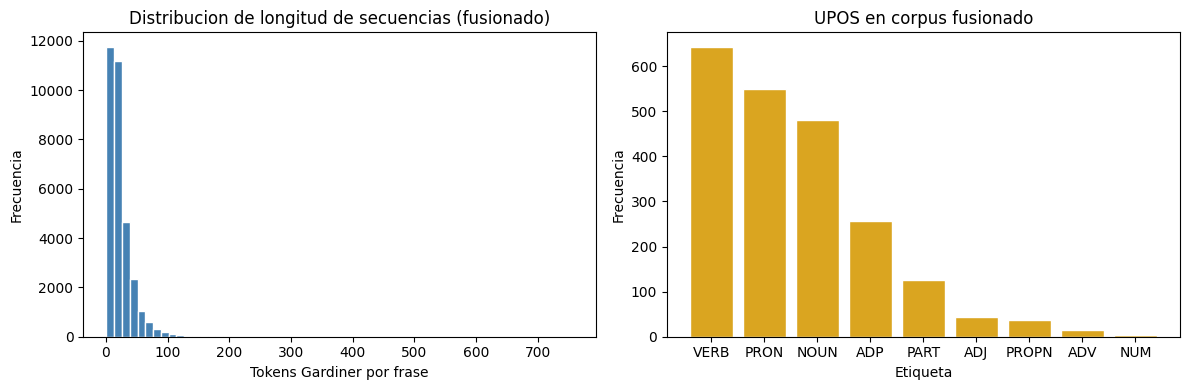

In [77]:
print('Reporte de calidad: sphinx_lexicon_master')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_fused['n_tokens'], bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de longitud de secuencias (fusionado)')
axes[0].set_xlabel('Tokens Gardiner por frase')
axes[0].set_ylabel('Frecuencia')

upos_all  = ' '.join(df_fused['upos_seq'].dropna().tolist()).split()
pos_final = Counter(upos_all)
lb, vl    = zip(*sorted(pos_final.items(), key=lambda x: -x[1]))
axes[1].bar(lb, vl, color='goldenrod', edgecolor='white')
axes[1].set_title('UPOS en corpus fusionado')
axes[1].set_xlabel('Etiqueta')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fused_quality_report.png', dpi=120)
plt.show()


In [80]:
all_g    = ' '.join(df_fused['gardiner_seq'].tolist()).split()
top_g    = Counter(all_g).most_common(25)
print('\nTop 5 IDs Gardiner in corpus:')
for gid, cnt in top_g:
    print(f'  {gid:<12} {cnt:>7,}')

all_t      = ' '.join(df_fused['translit_clean'].tolist()).split()
vocab_size = len(set(all_t))
print(f'\nPhoenic Vocabilsry unique : {vocab_size:,} difference tokens ')


Top 5 IDs Gardiner in corpus:
  X1            63,004
  N35           53,260
  D21           35,471
  M17           35,006
  Z1            33,810
  G17           23,428
  Z7            23,075
  Z2            21,012
  I9            20,753
  S29           17,392
  D36           14,902
  G1            14,249
  Y1            12,362
  V31           12,318
  Aa1           10,950
  G7             9,733
  A1             9,705
  V28            9,378
  Q3             9,065
  G43            8,952
  D46            8,528
  Z4             8,342
  N5             8,097
  D2             7,118
  D58            6,783

Phoenic Vocabilsry unique : 26,803 difference tokens 


In [81]:
print('\n-- Resumen final --')
print(f'  Entradas totales en el Trie : {len(df_fused):,}')
print(f'  Con payload TLA             : {n_con_tla:,}  ({pct_enriched:.1f}%)')
print(f'  Vocabulario fonetico        : {vocab_size:,} tokens')
print(f'  IDs Gardiner distintos      : {len(set(all_g)):,}')
print('\nListo para construir el Trie.')



-- Resumen final --
  Entradas totales en el Trie : 32,345
  Con payload TLA             : 678  (2.1%)
  Vocabulario fonetico        : 26,803 tokens
  IDs Gardiner distintos      : 1,364

Listo para construir el Trie.


In [82]:
import re
import json
import time
from pathlib import Path
from collections import Counter, defaultdict

In [83]:
import pandas as pd

In [84]:
OUTPUT_DIR = Path('/content/sphinx_data/output')
CLEAN_DIR  = Path('/content/sphinx_data/clean')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [85]:
df_b      = pd.read_parquet(CLEAN_DIR / 'bbaw_clean.parquet')
df_fused  = pd.read_parquet(OUTPUT_DIR / 'sphinx_lexicon_master.parquet')

In [86]:
print(f'bbaw_clean  : {len(df_b):,} registros')
print(f'fused master: {len(df_fused):,} registros')

bbaw_clean  : 32,345 registros
fused master: 32,345 registros


In [87]:
# =============================================================================
# BLOQUE 1 — GARDINER_MAP: fuente de verdad canonica
# =============================================================================
# Este diccionario es la base de todo el pipeline.
# Fuentes: Gardiner (1957), Allen (2010), TLA/BBAW, jsesh sign list.
#
# Convencion de valores:
#   - Signos foneticos    : su transliteracion Leiden directa  ('n', 'r', 'Htp')
#   - Determinativos      : cadena vacia ''  (no aportan fonetica)
#   - Signos ideograficos : su transliteracion con punto final ('pr.', 'nTr.')
#
# Los determinativos se mapean a '' para que validate_sequence los filtre
# y no contaminen la secuencia que se busca en el Trie.
# =============================================================================

In [88]:
GARDINER_MAP = {

    # --- A: Hombres y sus ocupaciones ---
    'A1'  : '',       # hombre sentado (determinativo general)
    'A2'  : '',       # hombre mano a boca (determinativo comer/hablar)
    'A3'  : '',       # hombre sentado en taburete
    'A4'  : '',       # hombre con mano a boca inclinado
    'A5'  : '',       # hombre agachado detras de muro
    'A6'  : '',       # hombre con tazón
    'A7'  : '',       # hombre cansado
    'A8'  : '',       # hombre bailando
    'A9'  : '',       # hombre con hilo
    'A10' : '',       # hombre con oar
    'A11' : '',       # hombre con mano extendida
    'A12' : '',       # soldado con arco y hacha
    'A13' : '',       # prisionero agachado
    'A14' : '',       # hombre cayendo con sangre
    'A15' : '',       # hombre cayendo
    'A17' : '',       # nino sentado
    'A19' : '',       # hombre apoyado en baston
    'A20' : '',       # hombre con baston y paquete
    'A21' : '',       # hombre con mano a pecho
    'A22' : '',       # estatua de hombre
    'A23' : '',       # rey con maza
    'A24' : '',       # hombre golpeando
    'A25' : '',       # hombre con manos sobre rodillas
    'A26' : '',       # hombre con mano levantada
    'A27' : '',       # hombre corriendo con mano atras
    'A28' : '',       # hombre con brazos levantados
    'A29' : '',       # hombre boca abajo
    'A30' : '',       # hombre con manos en adoracion
    'A32' : '',       # hombre bailando
    'A34' : '',       # hombre pisando
    'A35' : '',       # hombre construyendo
    'A36' : '',       # hombre en vasija
    'A37' : '',       # hombre en vasija invertida
    'A38' : '',       # hombre con cabeza de carnero
    'A40' : '',       # dios sentado
    'A41' : '',       # rey sentado
    'A42' : '',       # rey sentado con uraeus
    'A43' : '',       # rey con corona blanca
    'A44' : '',       # rey con corona roja
    'A45' : '',       # rey con corona Xpr
    'A46' : '',       # rey con corona Atf
    'A47' : '',       # pastor con capa
    'A48' : '',       # hombre con cabeza de halcon
    'A49' : '',       # hombre asiatico sentado
    'A50' : '',       # noble sentado
    'A51' : '',       # noble con flagelo
    'A52' : '',       # noble agachado
    'A53' : '',       # estatua
    'A54' : '',       # cuerpo muerto
    'A55' : '',       # cuerpo en mummy board
    'A56' : '',       # hombre sentado variante
    'A57' : '',       # hombre con vaso
    'A78' : '',       # hombre variante

    # --- B: Mujeres ---
    'B1'  : '',       # mujer sentada
    'B2'  : '',       # mujer embarazada
    'B3'  : '',       # mujer dando a luz
    'B4'  : '',       # mujer con mano a boca
    'B5'  : '',       # mujer con nino
    'B6'  : '',       # mujer con mano al pecho
    'B7'  : '',       # reina con corona
    'B8'  : '',       # mujer con uraeus

    # --- C: Dioses antropomorfos ---
    'C1'  : '',       # dios Ra
    'C2'  : '',       # dios con doble pluma
    'C3'  : '',       # dios Thoth
    'C4'  : '',       # dios con cabeza de carnero
    'C5'  : '',       # dios Ptah
    'C6'  : '',       # dios Osiris
    'C7'  : '',       # dios Set
    'C8'  : '',       # dios Khnum
    'C9'  : '',       # diosa con disco solar
    'C10' : '',       # diosa Maat
    'C11' : '',       # dios Atum
    'C12' : '',       # dios Min
    'C17' : '',       # dios Onuris

    # --- D: Partes del cuerpo humano ---
    'D1'  : 'tp',    # cabeza de perfil
    'D2'  : 'Hr',    # cara de frente
    'D3'  : 'Sny',   # cabello
    'D4'  : 'jr',    # ojo
    'D5'  : '',      # ojo con linea de kohl
    'D6'  : '',      # ojo con marca
    'D7'  : '',      # ojo con pincel
    'D8'  : '',      # pupila del ojo
    'D9'  : 'rmj',   # ojo con lagrima
    'D10' : 'wDAt',  # ojo udjat
    'D11' : '',      # variante ojo
    'D12' : '',      # pupila
    'D13' : '',      # ceja
    'D14' : '',      # media luna (ojo)
    'D15' : '',      # variante ojo
    'D16' : '',      # ceja con ojo
    'D17' : '',      # variante ojo
    'D18' : 'qnj',   # oreja
    'D19' : 'fnD',   # nariz y boca
    'D20' : 'ns',    # nariz con agua
    'D21' : 'r',     # boca
    'D22' : '',      # boca con linea
    'D23' : '',      # variante boca
    'D24' : '',      # labios
    'D25' : '',      # labios con diente
    'D26' : '',      # escupir
    'D27' : 'spt',   # labio
    'D28' : 'kA',    # dos brazos ka
    'D29' : '',      # variante ka
    'D30' : '',      # variante ka
    'D31' : '',      # brazo con palma abajo
    'D32' : 'Hnn',   # brazo abrazando
    'D33' : 'Xnm',   # brazo con remo
    'D34' : 'aHA',   # brazo con escudo y maza
    'D35' : 'n',     # brazo negativo (n de negacion)
    'D36' : 'a',     # brazo con palma arriba
    'D37' : 'mj',    # brazo con pan
    'D38' : '',      # brazo con pan variante
    'D39' : '',      # brazo con vaso
    'D40' : '',      # brazo con baston
    'D41' : 'jr',    # brazo hacia abajo (detener)
    'D42' : '',      # brazo variante
    'D43' : '',      # brazo extendido con flagelo
    'D44' : '',      # brazo con palma y flagelo
    'D45' : '',      # brazo con cuchillo
    'D46' : 'd',     # mano
    'D47' : '',      # palma de la mano
    'D48' : '',      # palma variante
    'D49' : '',      # puno
    'D50' : '',      # dedo
    'D51' : '',      # dedo variante
    'D52' : 'mt',    # falo
    'D53' : '',      # falo con agua
    'D54' : '',      # piernas caminando (determinativo movimiento)
    'D55' : '',      # pierna caminando atras
    'D56' : '',      # pierna
    'D57' : '',      # pierna con cuchillo
    'D58' : 'b',     # pierna y pie
    'D59' : '',      # pie variante
    'D60' : '',      # pie con vaso
    'D61' : '',      # dedo del pie
    'D62' : '',      # dedo del pie variante

    # --- E: Mamiferos ---
    'E1'  : 'kA',    # toro
    'E2'  : '',      # toro atacando
    'E3'  : '',      # toro en reposo variante
    'E4'  : '',      # vaca con becerro
    'E5'  : '',      # buey atado
    'E6'  : '',      # caballo
    'E7'  : '',      # asno
    'E8'  : 'jbA',   # cabra montesa
    'E9'  : '',      # ternero saltando
    'E10' : '',      # carnero con cuernos curvos
    'E11' : 'bA',    # carnero
    'E12' : '',      # cerdo
    'E13' : '',      # gato
    'E14' : '',      # perro
    'E15' : '',      # perro recostado
    'E16' : '',      # chacal recostado en templo
    'E17' : 'zA',    # chacal
    'E18' : '',      # chacal con flagelo
    'E19' : '',      # lobo en percha
    'E20' : '',      # lobo recostado
    'E21' : '',      # leon recostado variante
    'E22' : 'mAj',   # leon
    'E23' : 'rw',    # leon recostado
    'E24' : '',      # leopardo
    'E25' : '',      # hipopotamo
    'E26' : '',      # elefante
    'E27' : '',      # jirafa
    'E28' : '',      # oryx
    'E29' : 'nxt',   # cabra ibex
    'E30' : '',      # bouquetin
    'E31' : '',      # gacela
    'E32' : '',      # mono
    'E33' : '',      # mono sentado
    'E34' : '',      # liebre
    'E36' : '',      # rata
    'E37' : '',      # cerdo variante

    # --- F: Partes de mamiferos ---
    'F1'  : '',      # cabeza de buey de frente
    'F2'  : '',      # cabeza de buey de perfil
    'F3'  : '',      # cabeza de leopardo
    'F4'  : 'Xr',    # parte delantera de leon
    'F5'  : '',      # cabeza de buey con collar
    'F6'  : '',      # pecho
    'F7'  : '',      # cuerno de buey
    'F8'  : '',      # cuerno con vaso
    'F9'  : '',      # oreja de buey
    'F10' : '',      # oreja de buey variante
    'F11' : '',      # cabeza de gacela
    'F12' : 'wsr',   # cuello y cabeza de animal
    'F13' : 'wp',    # cuernos con hueso
    'F14' : '',      # cuerno largo
    'F15' : '',      # cuerno largo variante
    'F16' : '',      # marfil
    'F17' : '',      # marfil variante
    'F18' : '',      # colmillo de elefante
    'F19' : '',      # mandibula de buey
    'F20' : 'ns',    # lengua de buey
    'F21' : '',      # oreja de ternero
    'F22' : '',      # cuarto trasero de leon
    'F23' : '',      # cuarto trasero variante
    'F24' : '',      # cuarto trasero de buey
    'F25' : '',      # pata de buey
    'F26' : '',      # piel de animal
    'F27' : '',      # piel de animal con cola
    'F28' : '',      # piel de bovino
    'F29' : '',      # piel con flechas
    'F30' : '',      # bolsa de piel
    'F31' : 'ms',    # tres pieles de zorro
    'F32' : '',      # vientre de animal
    'F33' : '',      # cola
    'F34' : 'jb',    # corazon
    'F35' : 'nfr',   # corazon y traquea
    'F36' : '',      # pulmon
    'F37' : '',      # pulmon variante
    'F38' : '',      # espinazo
    'F39' : '',      # espinazo variante
    'F40' : 'Aw',    # espinazo con medula
    'F41' : '',      # costillas
    'F42' : '',      # pierna de bovino
    'F43' : '',      # huesos con carne
    'F44' : '',      # brazo de animal
    'F45' : '',      # utero
    'F46' : '',      # intestinos
    'F47' : '',      # intestinos enrollados
    'F48' : '',      # estomago
    'F49' : '',      # escarabajo pelotero (parte)
    'F51' : '',      # trozo de carne (determinativo)

    # --- G: Aves ---
    'G1'  : 'A',     # buitre egipcio (alef)
    'G2'  : 'AA',    # dos buitres
    'G3'  : 'Awt',   # ibis con cresta
    'G4'  : 'tjw',   # buitre variante
    'G5'  : 'Hr',    # halcon Horus
    'G6'  : '',      # halcon con flagelo
    'G7'  : '',      # halcon en percha (dios/rey)
    'G8'  : '',      # halcon en percha con flagelo
    'G9'  : '',      # halcon en cuenco
    'G10' : '',      # halcon en naos
    'G11' : '',      # halcon con disco solar
    'G12' : '',      # dos halcones
    'G13' : '',      # halcon con corona blanca
    'G14' : 'mt',    # buitre nekhbet
    'G15' : '',      # buitre con flagelo
    'G16' : '',      # dos buitres en cesto
    'G17' : 'm',     # buho
    'G18' : 'mm',    # dos buhos
    'G19' : '',      # buho con figura
    'G20' : 'm',     # buho variante
    'G21' : 'nH',    # pintada
    'G22' : '',      # pintada variante
    'G23' : '',      # ave de pecho marcado
    'G24' : '',      # ave sobre cuenco
    'G25' : 'Ax',    # ibis sagrado
    'G26' : 'DHwtj', # ibis de Thoth
    'G27' : '',      # flamenco
    'G28' : '',      # garza nocturna
    'G29' : 'bA',    # garza bA
    'G30' : '',      # tres garzas
    'G31' : '',      # grulla
    'G32' : '',      # grulla variante
    'G33' : '',      # grulla marchando
    'G34' : 'snD',   # avestruz
    'G35' : 'aw',    # cormorán
    'G36' : 'wr',    # golondrina
    'G37' : 'nDs',   # gorrion
    'G38' : '',      # ganso blanco
    'G39' : 'sA',    # ganso pintado
    'G40' : 'pA',    # pato en vuelo
    'G41' : 'xn',    # pato aterrizando
    'G42' : 'wSA',   # pato gordo
    'G43' : 'w',     # codorniz (waw)
    'G44' : '',      # dos codornices
    'G45' : 'wA',    # codorniz con brazo
    'G46' : '',      # codorniz variante
    'G47' : 't',     # pollo
    'G48' : '',      # nido con huevos
    'G49' : '',      # huevo en nido
    'G50' : '',      # dos patos
    'G51' : '',      # ave con pescado en boca
    'G52' : '',      # pato pintado (Seth)
    'G53' : '',      # halcon con paleta
    'G54' : 'snD',   # ave atada

    # --- H: Partes de aves ---
    'H1'  : '',      # cabeza de pato
    'H2'  : '',      # cabeza de halcon con corona
    'H3'  : '',      # cabeza de halcon
    'H4'  : '',      # cabeza de cobra
    'H5'  : '',      # ala
    'H6'  : 'Sw',    # pluma de Maat
    'H7'  : '',      # huevo
    'H8'  : '',      # huevo (determinativo)

    # --- I: Reptiles y anfibios ---
    'I1'  : 'mzH',   # cocodrilo
    'I2'  : '',      # cocodrilo con cola enrollada
    'I3'  : '',      # cocodrilo en mound
    'I4'  : '',      # cocodrilo con flagelo
    'I5'  : '',      # cocodrilo variante
    'I6'  : '',      # piel de cocodrilo
    'I7'  : '',      # rana
    'I8'  : '',      # renacuajo
    'I9'  : 'f',     # serpiente cornuda (fa)
    'I10' : 'D',     # cobra erguida (dj)
    'I11' : '',      # dos cobras
    'I12' : 'Dt',    # cobra con pluma
    'I13' : '',      # cobra en reposo
    'I14' : '',      # serpiente con cuernos
    'I15' : '',      # serpiente variante

    # --- K: Peces ---
    'K1'  : '',      # tilapia
    'K2'  : '',      # barbel
    'K3'  : '',      # mugil
    'K4'  : 'bw',    # siluro
    'K5'  : '',      # siluro variante
    'K6'  : '',      # escama de pez
    'K7'  : '',      # mormyrus
    'K8'  : '',      # latidae

    # --- L: Invertebrados y pequenos animales ---
    'L1'  : '',      # escarabajo pelotero (determinativo)
    'L2'  : 'ab',    # abeja
    'L3'  : '',      # mosca
    'L4'  : '',      # langosta
    'L5'  : '',      # ciempies
    'L6'  : '',      # concha

    # --- M: Plantas ---
    'M1'  : '',      # arbol (determinativo)
    'M2'  : '',      # planta (determinativo)
    'M3'  : 'xt',    # tronco de arbol
    'M4'  : 'rnp',   # palma con hojas de año
    'M5'  : '',      # palma variante
    'M6'  : 'nDm',   # planta del algarrobo
    'M7'  : '',      # rama de palma variante
    'M8'  : 'SA',    # lago de papiro
    'M9'  : 'xA',    # tallo de papiro con flor
    'M10' : '',      # tallo de papiro solo
    'M11' : '',      # flor de loto
    'M12' : '',      # loto con tallo largo
    'M13' : 'wAD',   # tallo de papiro
    'M14' : '',      # papiro con tallo enrollado
    'M15' : '',      # campo de papiros
    'M16' : '',      # campo de papiros variante
    'M17' : 'j',     # junco (yod)
    'M18' : 'jz',    # combinacion de juncos
    'M19' : '',      # granero de juncos
    'M20' : '',      # campo de juncos
    'M21' : '',      # cebada
    'M22' : 'nn',    # junco del norte
    'M23' : 'sw',    # junco del sur
    'M24' : '',      # junco del sur variante
    'M25' : '',      # flor sobre junco
    'M26' : '',      # junco florecido variante
    'M27' : '',      # planta herbácea
    'M28' : '',      # planta herbácea variante
    'M29' : 'nDt',   # vaina de semilla
    'M30' : '',      # raiz
    'M31' : '',      # espadaña
    'M32' : '',      # fruto de palma
    'M33' : '',      # granos de cebada
    'M34' : 'Dba',   # espiga de cereal
    'M36' : '',      # manojo de lino
    'M37' : '',      # manojo de plantas
    'M38' : '',      # manojo amplio
    'M39' : '',      # cesta de frutos
    'M40' : '',      # juncos
    'M41' : '',      # pedazo de madera
    'M42' : '',      # flor
    'M43' : '',      # vid en espaldera
    'M44' : '',      # espina

    # --- N: Cielo, tierra y agua ---
    'N1'  : 'pt',    # cielo
    'N2'  : '',      # cielo con sol
    'N3'  : '',      # cielo con sol y estrella
    'N4'  : '',      # cielo con lluvia
    'N5'  : 'ra',    # sol
    'N6'  : '',      # sol con uraeus
    'N7'  : '',      # sol variante
    'N8'  : 'Sps',   # sol brillante
    'N9'  : 'pH',    # luna llena
    'N10' : '',      # media luna
    'N11' : 'jAH',   # luna con media luna
    'N12' : '',      # media luna variante
    'N13' : '',      # luna y estrella
    'N14' : '',      # estrella
    'N15' : '',      # estrella en circulo
    'N16' : '',      # tierra plana con grano
    'N17' : 'tA',    # tierra plana
    'N18' : '',      # isla
    'N19' : '',      # dos tierras planas
    'N20' : '',      # franja de tierra
    'N21' : '',      # franja de tierra corta
    'N22' : '',      # desierto
    'N23' : '',      # canal
    'N24' : '',      # campo irrigado
    'N25' : 'xAst',  # colinas del desierto
    'N26' : '',      # montanas
    'N27' : 'Axt',   # sol entre montanas (horizonte)
    'N28' : 'xa',    # sol saliendo sobre colina
    'N29' : 'q',     # colina con abertura
    'N30' : '',      # colina con arbusto
    'N31' : '',      # camino con arbustos
    'N32' : '',      # terreno arenoso
    'N33' : '',      # grano de arena
    'N34' : '',      # lingote de metal
    'N35' : 'n',     # agua ondulada
    'N36' : 'mr',    # canal recto
    'N37' : 'S',     # estanque
    'N38' : '',      # estanque variante
    'N39' : '',      # estanque con planta
    'N40' : 'S',     # estanque variante
    'N41' : '',      # pozo
    'N42' : '',      # pozo variante

    # --- O: Edificios y partes de edificios ---
    'O1'  : 'pr',    # plano de casa
    'O2'  : '',      # casa con canal
    'O3'  : '',      # sala de columnas
    'O4'  : 'H',     # refugio de caña
    'O5'  : '',      # corral de caña
    'O6'  : '',      # recinto de templo
    'O7'  : '',      # pared de ladrillos
    'O8'  : '',      # pared variante
    'O9'  : '',      # fortaleza
    'O10' : '',      # palacio variante
    'O11' : 'aH',    # palacio
    'O12' : '',      # palacio variante
    'O13' : '',      # merlón de fortaleza
    'O14' : '',      # merlón variante
    'O15' : '',      # corte interior
    'O16' : '',      # puerta doble
    'O17' : '',      # puerta de pivot
    'O18' : '',      # capilla con techo
    'O19' : '',      # capilla en mound
    'O20' : 'Hwt',   # santuario Hwt
    'O21' : '',      # santuario variante
    'O22' : '',      # kiosko
    'O23' : '',      # base de pilar
    'O24' : '',      # piramide
    'O25' : '',      # obelisco
    'O26' : '',      # estela
    'O27' : '',      # columna
    'O28' : '',      # columna con capitel
    'O29' : 'aA',    # pilar aA
    'O30' : '',      # soporte de piedra
    'O31' : 'aA',    # puerta
    'O32' : '',      # portal de templo
    'O33' : 'aH',    # fachada de palacio
    'O34' : 'z',     # cerrojo
    'O35' : '',      # cerrojo con espiga
    'O36' : '',      # muro
    'O37' : '',      # muro derrumbado
    'O38' : '',      # esquina de muro
    'O39' : '',      # bloque de piedra
    'O40' : '',      # escalera
    'O41' : '',      # escalera doble
    'O42' : '',      # cercado de caña
    'O43' : '',      # cerca
    'O44' : '',      # cerca variante
    'O45' : '',      # domo
    'O46' : '',      # domo variante
    'O47' : '',      # recinto cuadrado
    'O48' : '',      # recinto variante
    'O49' : 'nwt',   # ciudad con calles en cruz
    'O50' : 'zp',    # era de trilla
    'O51' : '',      # granos en era

    # --- P: Barcos y partes ---
    'P1'  : 'dpt',   # barco
    'P2'  : '',      # barco con vela
    'P3'  : '',      # barco sagrado
    'P4'  : '',      # barco variante
    'P5'  : '',      # vela
    'P6'  : '',      # mástil
    'P7'  : '',      # mástil con vela
    'P8'  : 'Xrw',   # remo
    'P9'  : '',      # remo variante
    'P10' : '',      # timón
    'P11' : '',      # cabrestante

    # --- Q: Mobiliario domestico ---
    'Q1'  : '',      # trono (determinativo)
    'Q2'  : '',      # palanquín
    'Q3'  : 'p',     # taburete con patas de toro
    'Q4'  : '',      # reposacabezas
    'Q5'  : '',      # caja
    'Q6'  : '',      # sarcófago
    'Q7'  : '',      # brasero

    # --- R: Templo, ofrendas y mobiliario sacro ---
    'R1'  : '',      # mesa de ofrendas alta
    'R2'  : '',      # mesa variante
    'R3'  : '',      # mesa con ofrendas
    'R4'  : '',      # pan en estera (determinativo)
    'R5'  : '',      # brasero con llama
    'R6'  : '',      # incensario
    'R7'  : '',      # cuenco de incienso
    'R8'  : '',      # bandera en mástil
    'R9'  : '',      # bandera variante
    'R10' : '',      # bandera variante 2
    'R11' : 'Dd',    # pilar djed
    'R12' : '',      # estandarte de dios
    'R13' : '',      # estandarte variante
    'R14' : 'jmnt',  # pluma en estandarte (oeste)
    'R15' : 'jAbt',  # cetro en estandarte (este)
    'R16' : '',      # sceptro en estandarte
    'R17' : '',      # caja sagrada
    'R18' : '',      # bandeja de ofrendas
    'R19' : 'jpt',   # cetro con plumas
    'R20' : '',      # estela con pluma
    'R21' : '',      # estandarte con chacal
    'R22' : '',      # estandarte con ibis
    'R23' : '',      # estandarte con halcon
    'R24' : '',      # estandarte con loto

    # --- S: Coronas, ropa y bastones ---
    'S1'  : 'HDt',   # corona blanca del Alto Egipto
    'S2'  : '',      # corona blanca variante
    'S3'  : 'dSrt',  # corona roja del Bajo Egipto
    'S4'  : 'sxmtj', # doble corona
    'S5'  : '',      # doble corona variante
    'S6'  : '',      # corona variante
    'S7'  : '',      # corona azul
    'S8'  : '',      # corona Atef
    'S9'  : '',      # corona con cuernos
    'S10' : '',      # corona con plumas
    'S11' : 'wsx',   # collar wsx
    'S12' : 'nbw',   # collar de oro
    'S13' : '',      # collar variante
    'S14' : '',      # collar pectoral
    'S15' : '',      # pectoral variante
    'S16' : '',      # pectoral con pluma
    'S17' : '',      # pectoral con disco
    'S18' : '',      # collar menat
    'S19' : 'sDAw',  # sello cilíndrico
    'S20' : '',      # sello con asa
    'S21' : '',      # anillo
    'S22' : '',      # tela plegada con tira
    'S23' : '',      # tela variante
    'S24' : '',      # tela con cinturon
    'S25' : '',      # delantal
    'S26' : '',      # faldellín con cola
    'S27' : '',      # tela plegada
    'S28' : 'mnxt',  # tela plegada variante
    'S29' : 's',     # tela plegada en S (sa)
    'S30' : '',      # tela plegada variante
    'S31' : '',      # tela variante
    'S32' : '',      # tela con marcas
    'S33' : '',      # sandalia
    'S34' : 'anx',   # sandalia con tira
    'S35' : '',      # sombrilla
    'S36' : '',      # sombrilla variante
    'S37' : '',      # abanico
    'S38' : 'HqA',   # cayado de pastor
    'S39' : '',      # cayado variante
    'S40' : 'wAs',   # cetro was
    'S41' : 'Dam',   # cetro Dam
    'S42' : 'wAs',   # cetro con extremo animal
    'S43' : '',      # baston recto
    'S44' : '',      # baston con gancho
    'S45' : 'nxAx',  # flagelo
    'S46' : '',      # flagelo variante

    # --- T: Guerra, caza y carniceria ---
    'T1'  : '',      # maza con cabeza de pera
    'T2'  : '',      # maza con cabeza redonda
    'T3'  : 'Hm',    # maza con cabeza cilíndrica
    'T4'  : '',      # maza variante
    'T5'  : '',      # maza con extremo plano
    'T6'  : '',      # maza variante 2
    'T7'  : '',      # hacha
    'T8'  : 'xpS',   # cimitarra
    'T9'  : '',      # arco
    'T10' : '',      # arco variante
    'T11' : 'zwn',   # flecha
    'T12' : '',      # cuerda de arco
    'T13' : '',      # haz de flechas
    'T14' : 'wAD',   # escudo con flechas
    'T15' : 'qmA',   # hoz
    'T16' : '',      # hacha corta
    'T17' : '',      # silla de montar
    'T18' : '',      # cuchillo dentado
    'T19' : '',      # arpón con cuerda
    'T20' : '',      # arpón sin cuerda
    'T21' : 'qn',    # arpón simple
    'T22' : '',      # punta de flecha
    'T23' : '',      # punta variante
    'T24' : '',      # red
    'T25' : '',      # flotador de red
    'T26' : '',      # trampa de peces
    'T27' : '',      # trampa variante
    'T28' : 'nmt',   # bloque de carnicero
    'T29' : '',      # cuchillo y hueso
    'T30' : '',      # cuchillo
    'T31' : '',      # cuchillo variante
    'T32' : '',      # cuchillo de silex
    'T33' : '',      # cuchillo doble
    'T34' : '',      # cuchillo de carnicero

    # --- U: Agricultura y artesania ---
    'U1'  : 'mA',    # hoz
    'U2'  : '',      # hoz variante
    'U3'  : '',      # hoz variante 2
    'U4'  : '',      # hoz variante 3
    'U5'  : '',      # hoz variante 4
    'U6'  : 'mr',    # azada
    'U7'  : 'mr',    # azada variante
    'U8'  : '',      # azada variante 2
    'U9'  : '',      # pala
    'U10' : '',      # pala variante
    'U11' : '',      # arado
    'U12' : '',      # arado con toro
    'U13' : 'zb',    # arado simple
    'U14' : '',      # trineo
    'U15' : 'xnt',   # trineo variante
    'U16' : '',      # yugo
    'U17' : '',      # perforador
    'U18' : '',      # perforador variante
    'U19' : '',      # hacha de carpintero
    'U20' : '',      # hacha variante
    'U21' : '',      # adze
    'U22' : '',      # cincel
    'U23' : 'mr',    # cincel variante
    'U24' : '',      # buril
    'U25' : '',      # buril variante
    'U26' : '',      # pedernal
    'U27' : '',      # pedernal variante
    'U28' : '',      # brasero de fuego
    'U29' : '',      # brasero variante
    'U30' : 'nwt',   # horno para pan
    'U31' : '',      # mortero
    'U32' : '',      # mortero con mano
    'U33' : 'tj',    # pistilo
    'U34' : '',      # husillo
    'U35' : '',      # prensa de lino
    'U36' : 'Hm',    # malaquita
    'U37' : '',      # navaja
    'U38' : '',      # balanza
    'U39' : '',      # balanza variante
    'U40' : '',      # plomada

    # --- V: Cuerda, cesta y tela ---
    'V1'  : '',      # cuerda enrollada (cientos)
    'V2'  : '',      # cuerda enrollada variante
    'V3'  : '',      # cuerda enrollada corta
    'V4'  : 'wA',    # lazo
    'V5'  : '',      # lazo enrollado
    'V6'  : '',      # cuerda trenzada
    'V7'  : '',      # cuerda trenzada variante
    'V8'  : '',      # cuerda variante
    'V9'  : '',      # cuerda variante 2
    'V10' : '',      # cartucho
    'V11' : '',      # cartucho variante
    'V12' : '',      # cartucho variante 2
    'V13' : 'T',     # cuerda gruesa
    'V14' : '',      # cuerda doble
    'V15' : '',      # nudo de amarre
    'V16' : '',      # lazo de amarre
    'V17' : '',      # santuario de caña
    'V18' : '',      # santuario variante
    'V19' : 'mDH',   # cuerda enrollada variante
    'V20' : 'mD',    # correa o lazo (diez)
    'V22' : 'mH',    # lazo variante
    'V23' : '',      # lazo variante 2
    'V24' : '',      # lazo variante 3
    'V25' : '',      # lazo con flecha
    'V26' : '',      # cuerda con gancho
    'V27' : '',      # cuerda variante
    'V28' : 'H',     # mecha de lino
    'V29' : 'wDH',   # atado de lino
    'V30' : 'nb',    # canasta sin asa
    'V31' : 'k',     # canasta con asa
    'V32' : '',      # canasta variante
    'V33' : '',      # bolsa de piel
    'V34' : '',      # bolsa variante
    'V35' : '',      # bolsa variante 2
    'V36' : '',      # tela de lino
    'V37' : '',      # tela variante
    'V38' : '',      # tela doble
    'V39' : 'tjt',   # nudo de Isis

    # --- W: Vasijas de piedra y ceramica ---
    'W1'  : '',      # vaso de aceite con soporte
    'W2'  : '',      # vaso variante
    'W3'  : 'Hb',    # cuenco con base
    'W4'  : '',      # cuenco variante
    'W5'  : '',      # vaso con tapa
    'W6'  : '',      # vaso variante
    'W7'  : '',      # vaso de granito
    'W8'  : '',      # vaso de granito variante
    'W9'  : 'inH',   # vaso de alabastro
    'W10' : '',      # cuenco
    'W11' : 'nw',    # vaso nw
    'W12' : '',      # vaso variante
    'W13' : '',      # vaso variante 2
    'W14' : 'Hz',    # vaso Hz
    'W15' : '',      # vaso con agua
    'W16' : '',      # vaso con pluma
    'W17' : '',      # cuatro vasos nw
    'W18' : '',      # vaso variante
    'W19' : 'mi',    # vaso de leche
    'W20' : '',      # vaso variante
    'W21' : '',      # vaso de vino
    'W22' : 'Hnqt',  # jarra de cerveza
    'W23' : '',      # jarra variante
    'W24' : 'nw',    # vaso nw variante
    'W25' : '',      # vaso con tapa variante

    # --- X: Pan y pastelería ---
    'X1'  : 't',     # pan en forma de hogaza (te)
    'X2'  : '',      # pan en forma de cono
    'X3'  : '',      # pan en forma de torta
    'X4'  : '',      # pan variante
    'X5'  : '',      # pan variante 2
    'X6'  : '',      # pan redondo
    'X7'  : '',      # pan pequeno
    'X8'  : 'dj',    # pan conico (di)

    # --- Y: Escritura, juegos y musica ---
    'Y1'  : 'mDAt',  # papiro enrollado
    'Y2'  : '',      # papiro enrollado variante
    'Y3'  : 'sS',    # paleta de escriba
    'Y4'  : '',      # paleta con plumas
    'Y5'  : 'mn',    # tablero de juego
    'Y6'  : '',      # pieza de juego
    'Y7'  : '',      # arpa
    'Y8'  : '',      # sistrum

    # --- Z: Trazos y formas geometricas ---
    'Z1'  : '',      # trazo vertical (determinativo singular / ideograma)
    'Z2'  : '',      # tres trazos (determinativo plural)
    'Z3'  : '',      # tres trazos horizontal (plural abstracto)
    'Z4'  : 'j',     # dos trazos oblicuos (yod dual)
    'Z5'  : '',      # trazo oblicuo
    'Z6'  : '',      # trazo oblicuo variante
    'Z7'  : 'w',     # nudo de cuero (waw)
    'Z8'  : '',      # oval
    'Z9'  : '',      # lineas cruzadas
    'Z10' : '',      # lineas cruzadas variante
    'Z11' : '',      # dos lineas paralelas

    # --- Aa: Signos no clasificados ---
    'Aa1' : 'x',     # signo no clasificado (x / xpr)
    'Aa2' : 'qn',    # signo no clasificado
    'Aa5' : 'Hp',    # signo no clasificado
    'Aa7' : '',      # signo no clasificado
    'Aa8' : 'sr',    # signo no clasificado
    'Aa11': 'mAa',   # signo no clasificado
    'Aa13': '',      # signo no clasificado
    'Aa15': 'gs',    # signo no clasificado
    'Aa17': 'zA',    # signo no clasificado
    'Aa20': '',      # signo no clasificado
    'Aa27': 'q',     # signo no clasificado
    'Aa28': 'nD',    # signo no clasificado
    'Aa30': '',      # signo no clasificado
}


In [89]:
def gardiner_to_phonetic(gardiner_ids: list, gmap: dict) -> tuple:
    """
    Convierte una lista de IDs Gardiner a tokens foneticos,
    filtrando los determinativos (valor '') y los desconocidos.

    Retorna
    -------
    phonetic_tokens : list  tokens foneticos validos
    unmapped        : list  IDs sin cobertura en el mapa
    determinatives  : list  IDs reconocidos pero sin valor fonetico
    """
    phonetic_tokens = []
    unmapped        = []
    determinatives  = []

    for gid in gardiner_ids:
        if gid not in gmap:
            unmapped.append(gid)
        elif gmap[gid] == '':
            determinatives.append(gid)
        else:
            phonetic_tokens.append(gmap[gid])

    return phonetic_tokens, unmapped, determinatives


In [90]:
# Verificacion rapida del mapa
print('=' * 60)
print('Verificacion del GARDINER_MAP canonico')
print('=' * 60)
print(f'Total de signos en el mapa : {len(GARDINER_MAP)}')


Verificacion del GARDINER_MAP canonico
Total de signos en el mapa : 714


In [91]:
# Signos con valor fonetico
con_fonetica  = {k: v for k, v in GARDINER_MAP.items() if v != ''}
determinativos = {k: v for k, v in GARDINER_MAP.items() if v == ''}
print(f'Con valor fonetico         : {len(con_fonetica)}')
print(f'Determinativos (valor \"\") : {len(determinativos)}')

Con valor fonetico         : 175
Determinativos (valor "") : 539


In [92]:
print('\n-- Verificacion de IDs problematicos --')
for gid in ['M6', 'U15', 'D36', 'Z7', 'Aa1', 'Z1', 'Z2', 'Z3',
            'Z4', 'A1', 'A2', 'D54', 'F51', 'Aa2']:
    val = GARDINER_MAP.get(gid, 'FALTA EN EL MAPA')
    label = 'det' if val == '' else ('fonetico' if val != 'FALTA EN EL MAPA' else 'FALTA')
    print(f'  {gid:<8} [{label:<9}]  ->  "{val}"')


-- Verificacion de IDs problematicos --
  M6       [fonetico ]  ->  "nDm"
  U15      [fonetico ]  ->  "xnt"
  D36      [fonetico ]  ->  "a"
  Z7       [fonetico ]  ->  "w"
  Aa1      [fonetico ]  ->  "x"
  Z1       [det      ]  ->  ""
  Z2       [det      ]  ->  ""
  Z3       [det      ]  ->  ""
  Z4       [fonetico ]  ->  "j"
  A1       [det      ]  ->  ""
  A2       [det      ]  ->  ""
  D54      [det      ]  ->  ""
  F51      [det      ]  ->  ""
  Aa2      [fonetico ]  ->  "qn"


In [93]:
# =============================================================================
# BLOQUE 2 — TrieNode y SphinxTrie (version limpia)
# =============================================================================

In [97]:
class TrieNode:
    """
    Nodo del Trie de Sphinx.
    Los edges son tokens foneticos completos, no caracteres individuales.
    """
    __slots__ = ('children', 'is_end', 'payload', 'frequency')

    def __init__(self):
        self.children  : dict = {}
        self.is_end    : bool = False
        self.payload   : dict = None
        self.frequency : int  = 0


In [98]:
class SphinxTrie:
    """
    Trie de validacion lexica para el pipeline Sphinx.

    La clave de cada entrada es la secuencia fonetica de una frase
    del corpus bbaw, tokenizada por espacio:
        'nfr Htp sDm' -> ['nfr', 'Htp', 'sDm']

    Complejidad: insert O(L), search O(L), L = numero de tokens.
    """

    def __init__(self):
        self.root          = TrieNode()
        self.total_entries = 0
        self._all_phrases  = []

    def insert(self, phonetic_phrase: str, payload: dict = None) -> None:
        if not phonetic_phrase or not phonetic_phrase.strip():
            return
        tokens = phonetic_phrase.strip().split()
        node   = self.root
        for token in tokens:
            if token not in node.children:
                node.children[token] = TrieNode()
            node = node.children[token]
        node.frequency += 1
        if not node.is_end:
            node.is_end  = True
            node.payload = payload
            self.total_entries += 1
            self._all_phrases.append(phonetic_phrase.strip())
        else:
            if payload and node.payload:
                if not node.payload.get('tla_ids') and payload.get('tla_ids'):
                    node.payload = payload

    def search(self, phonetic_phrase: str) -> dict | None:
        node = self._traverse(phonetic_phrase)
        if node and node.is_end:
            return {'match': phonetic_phrase, 'payload': node.payload,
                    'frequency': node.frequency}
        return None

    def starts_with(self, prefix: str) -> bool:
        return self._traverse(prefix) is not None

    def autocomplete(self, prefix: str, max_results: int = 5) -> list:
        node = self._traverse(prefix)
        if node is None:
            return []
        results = []
        self._dfs_collect(node, prefix.strip().split(), results, max_results)
        return results

    def fuzzy_search(self, noisy_phrase: str,
                     max_distance: int = 2,
                     max_results: int  = 5) -> list:
        """
        Levenshtein a nivel de TOKEN (no caracter).
        Compara tuplas de tokens para que la distancia semantica sea correcta.
        """
        from rapidfuzz.distance import Levenshtein
        noisy_tokens = tuple(noisy_phrase.strip().split())
        candidates   = []
        for phrase in self._all_phrases:
            dist = Levenshtein.distance(
                noisy_tokens, tuple(phrase.split()),
                score_cutoff=max_distance
            )
            if dist <= max_distance:
                node = self._traverse(phrase)
                candidates.append({
                    'candidate' : phrase,
                    'distance'  : dist,
                    'payload'   : node.payload if node else None,
                    'frequency' : node.frequency if node else 0
                })
        candidates.sort(key=lambda x: (x['distance'], -x['frequency']))
        return candidates[:max_results]

    def save(self, filepath: str) -> None:
        data = {
            'total_entries': self.total_entries,
            'all_phrases'  : self._all_phrases,
            'trie'         : self._node_to_dict(self.root)
        }
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f'Trie guardado en: {filepath}')

    @classmethod
    def load(cls, filepath: str) -> 'SphinxTrie':
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        t               = cls()
        t.total_entries = data['total_entries']
        t._all_phrases  = data['all_phrases']
        t.root          = cls._dict_to_node(data['trie'])
        return t

    def _traverse(self, phrase: str) -> TrieNode | None:
        node = self.root
        for token in phrase.strip().split():
            if token not in node.children:
                return None
            node = node.children[token]
        return node

    def _dfs_collect(self, node, path, results, max_r):
        if len(results) >= max_r:
            return
        if node.is_end:
            results.append({'phrase': ' '.join(path),
                            'frequency': node.frequency,
                            'payload': node.payload})
        for char, child in node.children.items():
            self._dfs_collect(child, path + [char], results, max_r)

    def _node_to_dict(self, node):
        return {'is_end': node.is_end, 'frequency': node.frequency,
                'payload': node.payload,
                'children': {k: self._node_to_dict(v)
                             for k, v in node.children.items()}}

    @staticmethod
    def _dict_to_node(d):
        node           = TrieNode()
        node.is_end    = d['is_end']
        node.frequency = d['frequency']
        node.payload   = d['payload']
        node.children  = {k: SphinxTrie._dict_to_node(v)
                          for k, v in d['children'].items()}
        return node


In [99]:
# =============================================================================
# BLOQUE 3 — Construir el Trie desde el corpus bbaw
# =============================================================================
# La clave de insercion NO es la transliteracion raw del corpus.
# Es la SECUENCIA FONETICA que resultaria de aplicar GARDINER_MAP
# a la secuencia Gardiner de esa frase.
# Esto garantiza que lo que busca YOLO (secuencia Gardiner -> fonetica)
# coincide exactamente con lo que esta indexado en el Trie.

In [101]:
def build_trie_from_corpus(df: pd.DataFrame,
                            gmap: dict,
                            verbose: bool = True) -> SphinxTrie:
    """
    Construye el SphinxTrie desde el corpus bbaw fusionado.

    La clave de cada entrada es la secuencia fonetica derivada de
    aplicar GARDINER_MAP a la columna gardiner_seq de cada frase.
    Los determinativos se omiten. Los IDs sin cobertura se ignoran.

    Parametros
    ----------
    df      : DataFrame con columnas gardiner_seq, translit_clean,
              tla_ids, lemma_forms, upos_seq, date_before, date_after
    gmap    : GARDINER_MAP canonico
    verbose : imprimir estadisticas de construccion
    """
    trie              = SphinxTrie()
    skipped_no_phonetic = 0
    skipped_error       = 0
    inserted            = 0

    for _, row in df.iterrows():
        try:
            g_ids = row['gardiner_seq'].split()
            phonetic_tokens, unmapped, dets = gardiner_to_phonetic(g_ids, gmap)

            # Omitir frases que no producen ninguna fonetica
            # (ej. frases de solo determinativos)
            if not phonetic_tokens:
                skipped_no_phonetic += 1
                continue

            phonetic_phrase = ' '.join(phonetic_tokens)

            payload = {
                'gardiner_seq'  : row['gardiner_seq'],
                'translit_orig' : row.get('translit_clean', ''),
                'phonetic_key'  : phonetic_phrase,
                'tla_ids'       : row['tla_ids']     if isinstance(row.get('tla_ids'), list)     else None,
                'lemma_forms'   : row['lemma_forms'] if isinstance(row.get('lemma_forms'), list) else None,
                'upos_seq'      : row['upos_seq']    if pd.notna(row.get('upos_seq'))            else None,
                'date_before'   : int(row['date_before']) if pd.notna(row.get('date_before'))   else None,
                'date_after'    : int(row['date_after'])  if pd.notna(row.get('date_after'))    else None,
                'unmapped_ids'  : unmapped,
                'determinatives': dets,
            }
            trie.insert(phonetic_phrase, payload)
            inserted += 1

        except Exception:
            skipped_error += 1

    if verbose:
        print(f'Entradas insertadas         : {inserted:,}')
        print(f'Omitidas (sin fonetica)     : {skipped_no_phonetic:,}')
        print(f'Omitidas (error)            : {skipped_error:,}')
        print(f'Total en Trie               : {trie.total_entries:,}')

    return trie


In [102]:
print('\n' + '=' * 60)
print('Construyendo SphinxTrie v3')
print('=' * 60)
t0   = time.time()
trie = build_trie_from_corpus(df_fused, GARDINER_MAP, verbose=True)
t1   = time.time()
print(f'Tiempo de construccion      : {t1-t0:.2f}s')


Construyendo SphinxTrie v3
Entradas insertadas         : 32,214
Omitidas (sin fonetica)     : 131
Omitidas (error)            : 0
Total en Trie               : 30,908
Tiempo de construccion      : 6.52s


In [103]:
trie_path = str(OUTPUT_DIR / 'sphinx_trie_v3.json')
trie.save(trie_path)


Trie guardado en: /content/sphinx_data/output/sphinx_trie_v3.json


In [ ]:
# =============================================================================
# BLOQUE 4 — validate_sequence: interfaz YOLO -> Trie -> JSON para GPT
# =============================================================================

In [105]:
def validate_sequence(gardiner_ids    : list,
                      trie            : SphinxTrie,
                      gmap            : dict,
                      max_lev_dist    : int = 2,
                      max_suggestions : int = 3) -> dict:
    """
    Punto de entrada del pipeline.

    Recibe la lista de IDs Gardiner detectados por YOLOv11 y retorna
    un JSON estructurado listo para ser incluido en el prompt de GPT.

    Parametros
    ----------
    gardiner_ids    : IDs detectados por YOLO. Ej: ['G17','N35','D21']
    trie            : SphinxTrie ya construido y cargado
    gmap            : GARDINER_MAP canonico
    max_lev_dist    : tolerancia Levenshtein (default 2)
    max_suggestions : cuantas sugerencias incluir si status='corrected'

    Retorna
    -------
    {
        'input_gardiner'  : [...],
        'phonetic_seq'    : '...',   secuencia fonetica limpia (sin dets)
        'determinatives'  : [...],   IDs filtrados por ser determinativos
        'unmapped_ids'    : [...],   IDs sin cobertura en el mapa
        'status'          : 'exact' | 'corrected' | 'unknown',
        'matched_entry'   : '...',
        'payload'         : {...},
        'suggestions'     : [...],
        'confidence'      : float
    }
    """
    phonetic_tokens, unmapped, dets = gardiner_to_phonetic(gardiner_ids, gmap)
    phonetic_str = ' '.join(phonetic_tokens)

    result = {
        'input_gardiner' : gardiner_ids,
        'phonetic_seq'   : phonetic_str,
        'determinatives' : dets,
        'unmapped_ids'   : unmapped,
        'status'         : None,
        'matched_entry'  : None,
        'payload'        : None,
        'suggestions'    : [],
        'confidence'     : 0.0
    }

    if not phonetic_tokens:
        result['status']     = 'unknown'
        result['confidence'] = 0.0
        return result

    # Busqueda exacta
    exact = trie.search(phonetic_str)
    if exact:
        result['status']        = 'exact'
        result['matched_entry'] = exact['match']
        result['payload']       = exact['payload']
        result['confidence']    = 1.0
        return result

    # Levenshtein fuzzy
    fuzzy = trie.fuzzy_search(phonetic_str,
                               max_distance=max_lev_dist,
                               max_results=max_suggestions)
    if fuzzy:
        best               = fuzzy[0]
        confidence         = max(0.0, 1.0 - best['distance'] / (max_lev_dist + 1))
        result['status']        = 'corrected'
        result['matched_entry'] = best['candidate']
        result['payload']       = best['payload']
        result['confidence']    = round(confidence, 3)
        result['suggestions']   = [
            {'candidate': s['candidate'],
             'distance' : s['distance'],
             'frequency': s['frequency']}
            for s in fuzzy
        ]
    else:
        result['status']     = 'unknown'
        result['confidence'] = 0.0

    return result


In [106]:
# =============================================================================
# BLOQUE 5 — Tests del pipeline
# =============================================================================

In [107]:
print('\n' + '=' * 60)
print('Tests del pipeline v3')
print('=' * 60)


Tests del pipeline v3


In [123]:
# Test 1: secuencia del output que fallaba antes
test_ids_A = ['M17', 'Z7', 'Z3', 'D21', 'D21', 'N35', 'Z4', 'D28']
out_a      = validate_sequence(test_ids_A, trie, GARDINER_MAP)

In [124]:
print(f'\n[Test A] Input: {test_ids_A}')
print(f'  Secuencia fonetica : "{out_a["phonetic_seq"]}"')
print(f'  Determinativos     : {out_a["determinatives"]}')
print(f'  Unmapped IDs       : {out_a["unmapped_ids"]}')
print(f'  Status             : {out_a["status"]}')
print(f'  Confidence         : {out_a["confidence"]}')
if out_a['matched_entry']:
    print(f'  Match              : "{out_a["matched_entry"]}"')


[Test A] Input: ['M17', 'Z7', 'Z3', 'D21', 'D21', 'N35', 'Z4', 'D28']
  Secuencia fonetica : "j w r r n j kA"
  Determinativos     : ['Z3']
  Unmapped IDs       : []
  Status             : exact
  Confidence         : 1.0
  Match              : "j w r r n j kA"


In [128]:
# Test 2: secuencia ruidosa (X99 es ID falso de YOLO)
test_ids_B = ['X99', 'Z7', 'Z3', 'D21', 'D21', 'N35', 'Z4', 'D28']
out_b      = validate_sequence(test_ids_B, trie, GARDINER_MAP)

In [129]:
print(f'\n[Test B] Input ruidoso: {test_ids_B}')
print(f'  Secuencia fonetica : "{out_b["phonetic_seq"]}"')
print(f'  Unmapped IDs       : {out_b["unmapped_ids"]}')
print(f'  Status             : {out_b["status"]}')
print(f'  Confidence         : {out_b["confidence"]}')
if out_b['suggestions']:
    print(f'  Mejor sugerencia   : "{out_b["suggestions"][0]["candidate"]}" (dist={out_b["suggestions"][0]["distance"]})')



[Test B] Input ruidoso: ['X99', 'Z7', 'Z3', 'D21', 'D21', 'N35', 'Z4', 'D28']
  Secuencia fonetica : "w r r n j kA"
  Unmapped IDs       : ['X99']
  Status             : corrected
  Confidence         : 0.667
  Mejor sugerencia   : "j w r r n j kA" (dist=1)


In [136]:
# Test 3: frase conocida del Egipto Medio
# nfr = G17+I9+D21 en muchas inscripciones
test_ids_C =  ['D21', 'N35', 'Q3', 'M17' ,'M17' ,'X1'] #['D21','N35','Q3','M4','A17','A1']
out_c      = validate_sequence(test_ids_C, trie, GARDINER_MAP)

In [138]:
print(f'\n[Test C] nfr = {test_ids_C}')
print(f'  Secuencia fonetica : "{out_c["phonetic_seq"]}"')
print(f'  Status             : {out_c["status"]}')
print(f'  Confidence         : {out_c["confidence"]}')



[Test C] nfr = ['D21', 'N35', 'Q3', 'M17', 'M17', 'X1']
  Secuencia fonetica : "r n p j j t"
  Status             : corrected
  Confidence         : 0.333


In [117]:
# Test 4: autocomplete sobre prefijo fonetico
prefix = 'n r'
suggestions = trie.autocomplete(prefix, max_results=5)

In [118]:
print(f'\n[Test D] autocomplete("{prefix}"):')
for s in suggestions:
    print(f'  -> "{s["phrase"]}"  (freq={s["frequency"]})')


[Test D] autocomplete("n r"):
  -> "n r"  (freq=1)
  -> "n r n"  (freq=1)
  -> "n r n k"  (freq=1)
  -> "n r n Ax x t"  (freq=1)
  -> "n r n nmt r f"  (freq=1)


In [121]:
# Test 5: recarga desde disco
print('\n[Test E] Carga desde disco')
trie2    = SphinxTrie.load(trie_path)
out_reload = validate_sequence(test_ids_A, trie2, GARDINER_MAP)
print(f'  Status tras recarga: {out_reload["status"]}  (esperado: igual que Test A)')


[Test E] Carga desde disco
  Status tras recarga: exact  (esperado: igual que Test A)


In [139]:
import pickle, gzip

In [145]:
trie_path_bin = '/content/sphinx_data/output/sphinx_trie_v3.pkl.gz'

In [146]:
with gzip.open(trie_path_bin, 'wb', compresslevel=6) as f:
    pickle.dump(trie, f, protocol=pickle.HIGHEST_PROTOCOL)


In [142]:
size_mb = Path(trie_path_bin).stat().st_size / 1024 / 1024
print(f'Trie binario comprimido: {size_mb:.1f} MB')

Trie binario comprimido: 3.4 MB


In [147]:
with gzip.open(trie_path_bin, 'rb') as f:
    trie_loaded = pickle.load(f)


In [148]:
print(f'Entradas cargadas: {trie_loaded.total_entries:,}')

Entradas cargadas: 30,908


In [150]:
# Cuantas frases del corpus producen la misma phonetic_key
from collections import Counter


In [151]:

phonetic_keys = []
for _, row in df_fused.iterrows():
    g_ids = row['gardiner_seq'].split()
    tokens, _, _ = gardiner_to_phonetic(g_ids, GARDINER_MAP)
    if tokens:
        phonetic_keys.append(' '.join(tokens))

freq = Counter(phonetic_keys)
duplicados = {k: v for k, v in freq.items() if v > 1}

print(f'Total frases procesadas       : {len(phonetic_keys):,}')
print(f'Phonetic keys unicas          : {len(set(phonetic_keys)):,}')
print(f'Keys con colisiones           : {len(duplicados):,}')
print(f'Entradas perdidas por colision: {sum(v-1 for v in duplicados.values()):,}')
print(f'\nEjemplos de colisiones:')
for k, v in sorted(duplicados.items(), key=lambda x: -x[1])[:10]:
    print(f'  freq={v}  ->  "{k}"')

Total frases procesadas       : 32,214
Phonetic keys unicas          : 30,908
Keys con colisiones           : 769
Entradas perdidas por colision: 1,306

Ejemplos de colisiones:
  freq=33  ->  "Hnqt"
  freq=25  ->  "n"
  freq=22  ->  "r"
  freq=22  ->  "t"
  freq=19  ->  "nb"
  freq=19  ->  "w"
  freq=19  ->  "dj sw t dj t"
  freq=14  ->  "s"
  freq=11  ->  "m"
  freq=11  ->  "j"


In [152]:
print('\nPipeline Sphinx Trie v3 listo.')


Pipeline Sphinx Trie v3 listo.
